In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/canada-per-capita-income-prediction/Canada_per_capita_income (1).csv
/kaggle/input/d/nandhanasuresh/canada-per-capita-income/Canada_per_capita_income (1).csv


In [2]:
df=pd.read_csv("/kaggle/input/canada-per-capita-income-prediction/Canada_per_capita_income (1).csv")

In [3]:
df.head()

,year,income
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


In [4]:
x=df[['year']]

In [5]:
y=df['income']

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=1)

In [7]:
y_train

12     9619.438377
45    35175.188980
28    16622.671870
33    22739.426280
32    19232.175560
9      7602.912681
4      5576.514583
42    42665.255970
35    29198.055690
15    11018.955850
14    10790.328720
18    15080.283450
39    32755.176820
29    17581.024140
37    36144.481220
0      3399.299037
38    37446.486090
25    16369.317250
16    11482.891530
20    16838.673200
24    15755.820270
46    34229.193630
3      4804.463248
26    16699.826680
19    16426.725480
21    17266.097690
36    32738.262900
7      7100.126170
13    10416.536590
44    41039.893600
5      5998.144346
22    16412.083090
8      7247.967035
6      7062.131392
30    18987.382410
41    42334.711210
40    38420.522890
17    12974.806620
31    18601.397240
11     9434.390652
2      4251.175484
1      3768.297935
23    15875.586730
43    42676.468370
10     8355.968120
27    17310.757750
Name: income, dtype: float64

In [8]:
model=LinearRegression()

In [9]:
model.fit(x_train,y_train.to_numpy().reshape(-1,1))

LinearRegression()

In [10]:
x_train

,year
12,1982
45,2015
28,1998
33,2003
32,2002
9,1979
4,1974
42,2012
35,2005
15,1985


In [11]:
model.fit(x_train,y_train)

LinearRegression()

In [12]:
model.score(x_test,y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


nan

In [13]:
pred=model.predict(x_test)

In [14]:
mean_squared_error(y_test,pred)

5753780.290163675

In [15]:
r2_score(y_test,pred)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


nan

In [16]:
print(len(y_test))

1


In [17]:
 np.sqrt(mean_squared_error(y_test,pred))

np.float64(2398.70387713108)

In [18]:
y_test

34    25719.14715
Name: income, dtype: float64

In [20]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(x)

model.fit(X_poly, y)

accuracy = model.score(X_poly, y)
print("Improved Accuracy:", accuracy)

Improved Accuracy: 0.9290565008926308


In [25]:
submission = pd.DataFrame({
    'year': x_test['year'],
    'income': pred
})

# Save file


In [29]:
years = pd.DataFrame({
    'year': list(range(1960, 2026))   # full range
})
years_poly = poly.transform(years)   
pred = model.predict(years_poly)
submission = pd.DataFrame({
    'year': years['year'],
    'income': pred
})
submission.to_csv('/kaggle/working/submit.csv', index=False)

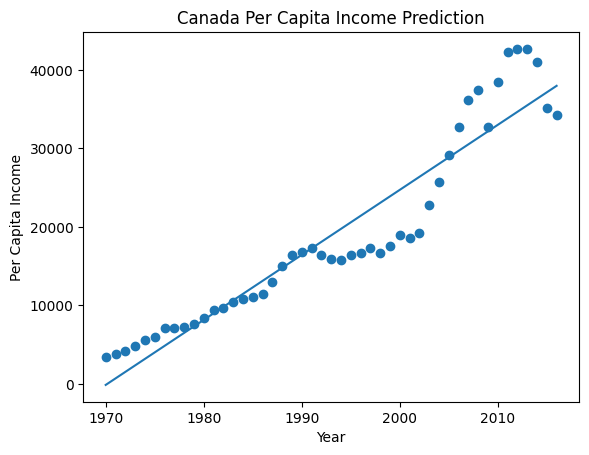

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Data
X = df[['year']]
y = df['income']

# Model fit
model.fit(X, y)

# Prediction line
y_pred_line = model.predict(X)

# Plot
plt.scatter(X, y)
plt.plot(X, y_pred_line)

plt.xlabel("Year")
plt.ylabel("Per Capita Income")
plt.title("Canada Per Capita Income Prediction")

plt.show()

In [31]:
plt.savefig('/kaggle/working/plot.png')

<Figure size 640x480 with 0 Axes>